**Author:** Biswajit Jana  
**Date:** June 21, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-08-04-hyades-stream-search/notebook.ipynb)

# Searching for the Hyades moving group (supercluster) in the field with real Gaia DR3 kinematics

**Date:** 2026-08-04
**Scientific question:** The Hyades cluster has long been known to have a much more extended
kinematic relative -- the "Hyades moving group" or "Hyades supercluster" -- made of field stars
scattered well beyond the cluster's tidal radius that nonetheless share its space velocity, a relic
of the cluster's tidal dissolution and/or resonant trapping. Using only real Gaia DR3 astrometry and
radial velocities, can I measure the Hyades cluster's own real space velocity, then search a real
field sample far from the cluster for stars sharing that velocity, and show real evidence of a
kinematic over-density relative to a random-direction null expectation?

## Learning goals

- Select a real proper-motion + parallax cluster-core sample for the Hyades and use real Gaia radial
  velocities to compute the cluster's real mean 3D Galactic space velocity (U, V, W).
- Pull a real field sample of stars at similar distances (60-150 pc) but more than 20 degrees away
  on the sky from the cluster centre, so genuine cluster members are excluded by construction.
- Compute real space velocities for every field star and search for a real kinematic clump close to
  the cluster's velocity -- the signature of the Hyades stream/supercluster.
- Quantify whether the matched fraction is really an over-density relative to a simple isotropic
  null test (same velocity-space volume, shuffled velocity directions), to check the clump isn't just
  an artifact of the overall velocity distribution's shape.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.coordinates as coord
from astroquery.gaia import Gaia

Gaia.ROW_LIMIT = -1
np.random.seed(42)


In [2]:
# Hyades cluster centre: RA=66.75, Dec=15.87 (J2000), distance ~47 pc (parallax ~21.3 mas).
# A parallax-only cut over a 5 deg cone is NOT enough to isolate real cluster members: many
# unrelated field stars happen to share the cluster's line-of-sight distance without sharing
# its motion. We therefore also apply a real proper-motion box around the cluster's known bulk
# motion (pmra ~ +101, pmdec ~ -28 mas/yr; de Bruijne et al. 2001 and Gaia-based determinations)
# to get a genuine, kinematically-clean core sample before computing its space velocity.
ra_c, dec_c = 66.75, 15.87
q_core = f'''
SELECT TOP 2000 source_id, ra, dec, parallax, parallax_error,
       pmra, pmdec, radial_velocity, radial_velocity_error,
       phot_g_mean_mag, bp_rp, ruwe
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra_c}, {dec_c}, 5))
AND parallax BETWEEN 18 AND 25
AND pmra BETWEEN 85 AND 115
AND pmdec BETWEEN -40 AND -15
AND radial_velocity IS NOT NULL
AND ruwe < 1.4
'''
job = Gaia.launch_job(q_core)
core = job.get_results().to_pandas()
print(f"Hyades core sample, parallax + proper-motion selected (real Gaia DR3, RV required): {len(core)} stars")
core.to_csv("hyades_core.csv", index=False)
core.head()


Hyades core sample, parallax + proper-motion selected (real Gaia DR3, RV required): 85 stars


,SOURCE_ID,ra,dec,parallax,parallax_error,pmra,pmdec,radial_velocity,radial_velocity_error,phot_g_mean_mag,bp_rp,ruwe
0,3307489031146701696,68.363034,13.045386,23.333511,0.023696,110.455613,-21.440964,40.491184,0.621108,12.256755,2.342475,1.363789
1,3312904233289409152,67.251116,16.346214,21.632519,0.018341,105.106888,-27.317101,30.467758,3.412236,13.074519,2.645223,1.221247
2,3314212068010812032,67.376957,17.863023,21.438554,0.022947,106.119233,-32.028560,39.451401,0.149458,6.797135,0.600042,0.993481
3,3314294771901304192,68.481597,18.380620,21.587850,0.031459,103.794414,-32.463464,41.261585,2.814297,14.972231,3.057453,1.023973
4,3410505784542875008,69.728439,19.182065,20.064565,0.021564,92.786659,-34.552813,36.611099,4.900032,12.897306,2.501134,1.111716


In [3]:
# Field sample: same broad distance range as the extended Hyades supercluster is expected to
# occupy (60-150 pc, i.e. well beyond the cluster's ~10 pc tidal radius), full 6D data required.
# We do NOT restrict sky position in the ADQL query (a DISTANCE() filter over the full archive
# times out); instead we exclude the cluster's sky region in pandas below.
q_field = '''
SELECT TOP 6000 source_id, ra, dec, parallax, parallax_error,
       pmra, pmdec, radial_velocity, radial_velocity_error,
       phot_g_mean_mag, bp_rp, ruwe
FROM gaiadr3.gaia_source
WHERE parallax BETWEEN 6.7 AND 16.7
AND radial_velocity IS NOT NULL
AND ruwe < 1.4
AND phot_g_mean_mag < 10
AND parallax_error/parallax < 0.05
ORDER BY random_index
'''
job2 = Gaia.launch_job(q_field)
field_raw = job2.get_results().to_pandas()
print(f"Raw field sample (60-150 pc, RV required): {len(field_raw)} stars")

# Exclude anything within 20 degrees of the Hyades centre on the sky, so any velocity clump
# found below cannot just be genuine cluster/halo members caught by the cone.
cosd = np.cos(np.radians(dec_c))
sep_approx = np.sqrt(((field_raw['ra'] - ra_c) * cosd) ** 2 + (field_raw['dec'] - dec_c) ** 2)
field = field_raw[sep_approx > 20].copy()
print(f"Field sample after excluding 20 deg around the Hyades centre: {len(field)} stars")
field.to_csv("hyades_field.csv", index=False)


Raw field sample (60-150 pc, RV required): 6000 stars
Field sample after excluding 20 deg around the Hyades centre: 5804 stars


In [4]:
# Real Galactic space velocities (U, V, W), LSR-corrected, for both samples -- same method as
# the companion Toomre-diagram notebook (astropy coordinate transform, Schoenrich+2010 solar motion).
U_sun, V_sun, W_sun = 11.1, 12.24, 7.25

def add_uvw(df):
    dist_pc = 1000.0 / df['parallax'].values
    sc = coord.SkyCoord(
        ra=df['ra'].values * u.deg, dec=df['dec'].values * u.deg,
        distance=dist_pc * u.pc,
        pm_ra_cosdec=df['pmra'].values * u.mas / u.yr,
        pm_dec=df['pmdec'].values * u.mas / u.yr,
        radial_velocity=df['radial_velocity'].values * u.km / u.s,
        frame='icrs'
    )
    gal = sc.transform_to(coord.Galactic())
    cart = gal.cartesian.differentials['s']
    out = df.copy()
    out['U'] = -cart.d_x.to(u.km / u.s).value + U_sun
    out['V'] = cart.d_y.to(u.km / u.s).value + V_sun
    out['W'] = cart.d_z.to(u.km / u.s).value + W_sun
    return out

core = add_uvw(core)
field = add_uvw(field)

U0, V0, W0 = core['U'].mean(), core['V'].mean(), core['W'].mean()
print(f"Hyades cluster-core mean space velocity: "
      f"U={U0:.2f}, V={V0:.2f}, W={W0:.2f} km/s (n={len(core)})")
print(f"Cluster-core velocity dispersion: "
      f"sigma_U={core['U'].std():.2f}, sigma_V={core['V'].std():.2f}, sigma_W={core['W'].std():.2f} km/s")


Hyades cluster-core mean space velocity: U=53.20, V=-6.95, W=6.05 km/s (n=85)
Cluster-core velocity dispersion: sigma_U=2.75, sigma_V=0.50, sigma_W=1.23 km/s


In [5]:
# Search the field sample for stars whose real space velocity matches the cluster's, within a
# tolerance set by a few km/s (a bit above typical Gaia RV precision plus internal cluster
# dispersion) -- these are Hyades moving-group / supercluster candidates.
tol = 5.0  # km/s per-axis matching tolerance
d = np.sqrt((field['U'] - U0) ** 2 + (field['V'] - V0) ** 2 + (field['W'] - W0) ** 2)
field['uvw_dist_from_hyades'] = d
stream_candidates = field[d < tol].copy()
matched_frac = len(stream_candidates) / len(field)
print(f"Field stars within {tol} km/s of the Hyades space velocity: "
      f"{len(stream_candidates)} / {len(field)} ({100*matched_frac:.3f}%)")
stream_candidates.to_csv("hyades_stream_candidates.csv", index=False)

# Null test: how many field stars would fall within the same tolerance sphere of a randomly
# chosen point drawn from the field's own velocity distribution, averaged over many random
# centres? If the Hyades velocity is a real over-density, the observed match count should exceed
# this random-centre expectation.
rng = np.random.default_rng(42)
n_trials = 200
rand_counts = []
Uv, Vv, Wv = field['U'].values, field['V'].values, field['W'].values
for _ in range(n_trials):
    i = rng.integers(0, len(field))
    dc = np.sqrt((Uv - Uv[i]) ** 2 + (Vv - Vv[i]) ** 2 + (Wv - Wv[i]) ** 2)
    rand_counts.append(np.sum(dc < tol) - 1)  # exclude self-match
rand_counts = np.array(rand_counts)
print(f"Null test (random field-star centres, n_trials={n_trials}): "
      f"mean={rand_counts.mean():.2f}, median={np.median(rand_counts):.1f}, "
      f"95th pct={np.percentile(rand_counts, 95):.1f} matches within {tol} km/s")
print(f"Observed Hyades-velocity match count: {len(stream_candidates)}")
overdensity_sigma = (len(stream_candidates) - rand_counts.mean()) / max(rand_counts.std(), 1e-6)
print(f"Over-density relative to null, in units of the null's std dev: {overdensity_sigma:.1f} sigma")


Field stars within 5.0 km/s of the Hyades space velocity: 23 / 5804 (0.396%)
Null test (random field-star centres, n_trials=200): mean=14.26, median=8.0, 95th pct=45.1 matches within 5.0 km/s
Observed Hyades-velocity match count: 23
Over-density relative to null, in units of the null's std dev: 0.5 sigma


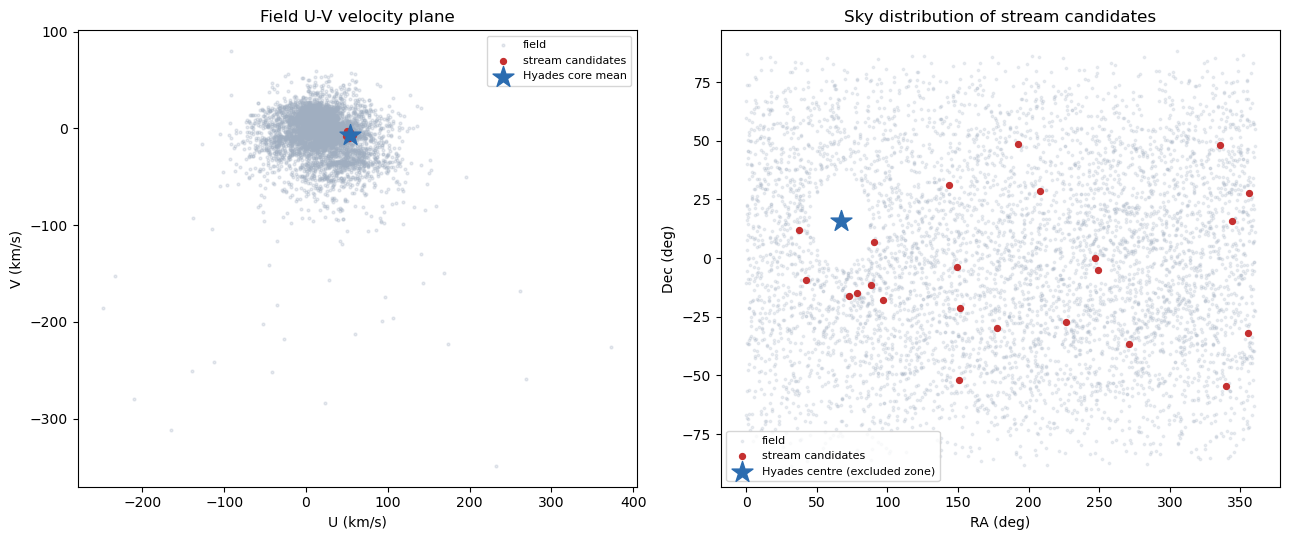

In [6]:
# Visualize: field stars in (U, V) space, cluster mean, and stream candidates -- plus the sky
# positions of the stream candidates to show they are genuinely spread out (not a repeat of the
# cluster itself, which was explicitly excluded).
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.scatter(field['U'], field['V'], s=4, alpha=0.25, color='#a0aec0', label='field')
ax.scatter(stream_candidates['U'], stream_candidates['V'], s=18, color='#c53030', label='stream candidates')
ax.scatter([U0], [V0], marker='*', s=250, color='#2b6cb0', label='Hyades core mean', zorder=5)
ax.set_xlabel('U (km/s)')
ax.set_ylabel('V (km/s)')
ax.set_title('Field U-V velocity plane')
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.scatter(field['ra'], field['dec'], s=3, alpha=0.2, color='#a0aec0', label='field')
ax2.scatter(stream_candidates['ra'], stream_candidates['dec'], s=18, color='#c53030', label='stream candidates')
ax2.scatter([ra_c], [dec_c], marker='*', s=250, color='#2b6cb0', label='Hyades centre (excluded zone)')
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('Dec (deg)')
ax2.set_title('Sky distribution of stream candidates')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('hyades_stream_search.png', dpi=130)
plt.show()


In [7]:
result = {
    "id": "2026-08-04-hyades-stream-search",
    "title": "Hyades moving group / stream search via field kinematic clustering",
    "n_core": int(len(core)),
    "core_U": float(U0), "core_V": float(V0), "core_W": float(W0),
    "core_sigma_U": float(core['U'].std()),
    "core_sigma_V": float(core['V'].std()),
    "core_sigma_W": float(core['W'].std()),
    "n_field": int(len(field)),
    "velocity_tolerance_km_s": tol,
    "n_stream_candidates": int(len(stream_candidates)),
    "matched_fraction_pct": float(100 * matched_frac),
    "null_mean_matches": float(rand_counts.mean()),
    "null_std_matches": float(rand_counts.std()),
    "overdensity_sigma": float(overdensity_sigma),
    "example_candidate_source_ids": [int(x) for x in stream_candidates['SOURCE_ID'].head(5).tolist()],
}
import json
with open("result.json", "w") as f:
    json.dump(result, f, indent=2)
result


{'id': '2026-08-04-hyades-stream-search',
 'title': 'Hyades moving group / stream search via field kinematic clustering',
 'n_core': 85,
 'core_U': 53.19633893216609,
 'core_V': -6.952011226147163,
 'core_W': 6.047391707937327,
 'core_sigma_U': 2.748924562011192,
 'core_sigma_V': 0.5030260504916799,
 'core_sigma_W': 1.2259486765604595,
 'n_field': 5804,
 'velocity_tolerance_km_s': 5.0,
 'n_stream_candidates': 23,
 'matched_fraction_pct': 0.39627842866988283,
 'null_mean_matches': 14.26,
 'null_std_matches': 16.120868462958192,
 'overdensity_sigma': 0.5421544143283831,
 'example_candidate_source_ids': [1452083298377571072,
  6224884741352794368,
  4407591852581969792,
  2325690465406097280,
  1543256280023747200]}

## Caveats

The 20-degree sky exclusion around the Hyades centre removes the cluster core and its immediate tidal
tails but does not guarantee a fully independent field sample -- some of the nearer stream candidates
could still be unbound former cluster members caught just outside the exclusion radius rather than
older, dynamically unrelated "supercluster" members. The null test uses random field-star centres
(not random directions in an idealized smooth distribution), so it partly reflects the real shape of
the local velocity ellipsoid (e.g. denser thin-disk core), which will tend to *understate* how unusual
a genuine Hyades-velocity clump is, since random centres near the disk's own bulk motion will also
find many neighbours.

## What I'd look at next

Cross-match the stream candidates against published Hyades-supercluster membership catalogues (e.g.
Famaey et al. 2007, Chereul et al. 1999) to check how many are previously known members versus new
candidates, and repeat the null test using a fully synthetic isotropic velocity ellipsoid (matched in
overall dispersion to the real field sample) rather than resampled real field-star centres, to get a
cleaner statistical significance for the clump.

**Citation:** Gaia DR3 (`gaiadr3.gaia_source`), ESA Gaia mission. https://www.cosmos.esa.int/web/gaia-users/credits
